In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../outputs/cleaned_data.csv"
OUT_PATH = "../outputs/route_clusters.csv"
N_CLUSTERS = 4

In [2]:
df = pd.read_csv(DATA_PATH)

route_perf = (
    df.groupby(["Region", "Product Name", "Factory"])
    .agg(
        avg_lead_time=("Lead Time", "mean"),
        order_count=("Order ID", "count"),
        avg_distance_km=("Shipping_Distance_KM", "mean"),
        avg_profit_margin=("Profit_Margin", "mean"),
        total_units=("Units", "sum"),
    )
    .reset_index()
)

route_perf.head()

,Region,Product Name,Factory,avg_lead_time,order_count,avg_distance_km,avg_profit_margin,total_units
0,Atlantic,Fizzy Lifting Drinks,Sugar Shack,4.075000,2,1751.618523,0.600000,9
1,Atlantic,Fun Dip,Sugar Shack,6.830000,1,1784.794705,0.400000,4
2,Atlantic,Hair Toffee,The Other Factory,6.500000,1,1518.732306,0.777778,5
3,Atlantic,Kazookles,The Other Factory,4.566538,26,1432.366086,0.076923,70
4,Atlantic,Laffy Taffy,Sugar Shack,4.783333,6,1758.997973,0.623116,14


In [3]:
features = ["avg_lead_time", "avg_distance_km", "avg_profit_margin", "order_count"]
X = StandardScaler().fit_transform(route_perf[features])

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
route_perf["Cluster"] = km.fit_predict(X)

route_perf.head()

,Region,Product Name,Factory,avg_lead_time,order_count,avg_distance_km,avg_profit_margin,total_units,Cluster
0,Atlantic,Fizzy Lifting Drinks,Sugar Shack,4.075000,2,1751.618523,0.600000,9,1
1,Atlantic,Fun Dip,Sugar Shack,6.830000,1,1784.794705,0.400000,4,0
2,Atlantic,Hair Toffee,The Other Factory,6.500000,1,1518.732306,0.777778,5,0
3,Atlantic,Kazookles,The Other Factory,4.566538,26,1432.366086,0.076923,70,1
4,Atlantic,Laffy Taffy,Sugar Shack,4.783333,6,1758.997973,0.623116,14,0


In [4]:
cluster_rank = route_perf.groupby("Cluster")["avg_lead_time"].mean().sort_values(ascending=False)
cluster_rank

Cluster
0    6.098718
2    4.878317
3    4.804891
1    3.611947
Name: avg_lead_time, dtype: float64

In [5]:
label_map = {
    cluster_rank.index[0]: "Consistently Slow",
    cluster_rank.index[1]: "Below Average",
    cluster_rank.index[2]: "Above Average",
    cluster_rank.index[3]: "Fast & Efficient",
}
route_perf["Cluster_Label"] = route_perf["Cluster"].map(label_map)

route_perf.groupby("Cluster_Label")[
    ["avg_lead_time", "avg_distance_km", "avg_profit_margin", "order_count"]
].mean().round(3).sort_values("avg_lead_time", ascending=False)

,avg_lead_time,avg_distance_km,avg_profit_margin,order_count
Cluster_Label,,,,
Consistently Slow,6.099,1739.719,0.596,2.231
Below Average,4.878,1236.038,0.671,493.667
Above Average,4.805,3090.147,0.681,485.250
Fast & Efficient,3.612,1432.025,0.443,12.353


In [6]:
slow_routes = route_perf[route_perf["Cluster_Label"] == "Consistently Slow"].sort_values(
    "order_count", ascending=False
)

slow_routes[["Region", "Product Name", "Factory", "avg_lead_time", "order_count"]].head(10)

,Region,Product Name,Factory,avg_lead_time,order_count
4,Atlantic,Laffy Taffy,Sugar Shack,4.783333,6
7,Atlantic,SweeTARTS,Sugar Shack,6.030000,5
6,Atlantic,Nerds,Sugar Shack,6.587500,4
32,Interior,SweeTARTS,Sugar Shack,5.137500,4
19,Gulf,Laffy Taffy,Sugar Shack,5.905000,2
2,Atlantic,Hair Toffee,The Other Factory,6.500000,1
1,Atlantic,Fun Dip,Sugar Shack,6.830000,1
15,Gulf,Fizzy Lifting Drinks,Sugar Shack,6.590000,1
14,Gulf,Everlasting Gobstopper,Secret Factory,6.390000,1
26,Interior,Everlasting Gobstopper,Secret Factory,6.610000,1


In [7]:
route_perf.to_csv(OUT_PATH, index=False)
print(f"Saved {len(route_perf)} route clusters to {OUT_PATH}")

Saved 50 route clusters to ../outputs/route_clusters.csv


In [8]:
route_perf["total_profit_estimate"] = route_perf["avg_profit_margin"] * route_perf["total_units"]

route_perf.groupby("Cluster_Label")[
    ["avg_lead_time", "order_count", "total_units", "total_profit_estimate"]
].sum(numeric_only=True).round(1).sort_values("order_count", ascending=False)

,avg_lead_time,order_count,total_units,total_profit_estimate
Cluster_Label,,,,
Below Average,58.5,5924,22113,14874.4
Above Average,38.4,3882,14638,9911.0
Fast & Efficient,61.4,210,743,289.3
Consistently Slow,79.3,29,97,53.9


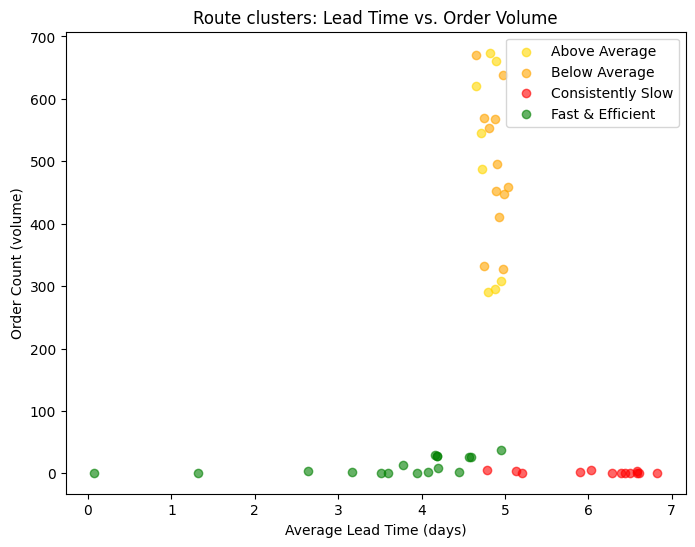

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Consistently Slow": "red", "Below Average": "orange",
          "Above Average": "gold", "Fast & Efficient": "green"}

for label, group in route_perf.groupby("Cluster_Label"):
    ax.scatter(group["avg_lead_time"], group["order_count"],
               label=label, alpha=0.6, color=colors[label])

ax.set_xlabel("Average Lead Time (days)")
ax.set_ylabel("Order Count (volume)")
ax.set_title("Route clusters: Lead Time vs. Order Volume")
ax.legend()
plt.show()